# Dataset与DataLoader

In [5]:
import os
import pandas as pd
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset, Subset
from PIL import Image
import torch


# 设置数据目录与标签CSV路径
data_dir = r"/mnt/workspace/cifar-10/train/train"
labels_csv = r"/mnt/workspace/cifar-10/trainLabels.csv"

# 1. 定义 CIFAR-10 的类别到整数索引的映射
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}

# 2. 加载标签CSV
df = pd.read_csv(labels_csv)
file_to_label = {}
for idx, row in df.iterrows():
    # 【修复关键点1】直接使用 id 和 .png 后缀，不补零
    file_name = f"{row['id']}.png"
    # 【修复关键点2】将字符串标签（如"frog"）转换为数字标签（如6）
    file_to_label[file_name] = class_to_idx[row['label']]

# 训练集使用数据增强抑制过拟合；验证集和测试集只做归一化。
normalize = transforms.Normalize((0.4917, 0.4823, 0.4467), (0.2024, 0.1995, 0.2010))
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    normalize,
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.15), value='random'),
])
val_transform = transforms.Compose([
    transforms.ToTensor(),
    normalize,
])
# 保留 transform 名称供最后的测试集代码使用。
transform = val_transform

class MyImageDataset(Dataset):
    def __init__(self, folder, file_to_label, transform=None):
        self.folder = folder
        self.transform = transform
        self.file_to_label = file_to_label
        
        self.img_files = []
        for f in os.listdir(folder):
            if f.endswith(('.jpg', '.jpeg', '.png')):
                if f in self.file_to_label:
                    self.img_files.append(os.path.join(folder, f))
        
        # 按照文件名中的数字进行排序，保证顺序一致
        self.img_files.sort(key=lambda x: int(os.path.basename(x).split('.')[0]))
        
        # 打印一下实际加载到的图片数量，确保不再是 0
        print(f"成功匹配到 {len(self.img_files)} 张图片！")
        
    def __len__(self):
        return len(self.img_files)
    
    def __getitem__(self, idx):
        img_path = self.img_files[idx]
        image = Image.open(img_path).convert('RGB')
        basename = os.path.basename(img_path)
        
        # 此时获取到的已经是整数标签了
        label = self.file_to_label[basename]
        
        if self.transform:
            image = self.transform(image)
        return image, label

# 两份 Dataset 共享相同图片和划分索引，但分别使用训练/验证变换。
train_full_dataset = MyImageDataset(data_dir, file_to_label, transform=train_transform)
val_full_dataset = MyImageDataset(data_dir, file_to_label, transform=val_transform)
full_dataset = val_full_dataset
total_size = len(train_full_dataset)

# 固定随机种子，使每次运行都得到相同的训练/验证划分。
train_size = int(total_size * 0.9)
generator = torch.Generator().manual_seed(42)
indices = torch.randperm(total_size, generator=generator).tolist()
train_dataset = Subset(train_full_dataset, indices[:train_size])
val_dataset = Subset(val_full_dataset, indices[train_size:])

print(f"训练集大小: {len(train_dataset)}, 验证集大小: {len(val_dataset)}")

# 构造DataLoader
batch_size = 128
trainloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
valloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

成功匹配到 50000 张图片！
成功匹配到 50000 张图片！
训练集大小: 45000, 验证集大小: 5000


In [6]:
train_dataset[0][0].shape

torch.Size([3, 32, 32])

In [7]:
full_dataset[0][1]

6

In [8]:
for images, labels in trainloader:
    print(images.shape, labels.shape)
    break

torch.Size([128, 3, 32, 32]) torch.Size([128])


# 搭建模型

In [9]:
import torch  # 导入PyTorch主库
import torch.nn as nn  # 导入PyTorch的神经网络模块

# 残差基本模块定义
class ResidualBlock(nn.Module):  # 继承nn.Module，定义残差块
    expansion = 1  # 控制定义resnet结构时通道的扩展因子，这里为1（不变）

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):  # 构造函数，指定输入输出通道数、步幅和下采样模块
        super(ResidualBlock, self).__init__()  # 调用父类构造函数
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)  # 第一个3x3卷积层（可带步幅）
        self.bn1 = nn.BatchNorm2d(out_channels)  # 第一个BN层，作用在conv1输出上
        self.relu = nn.ReLU(inplace=True)  # ReLU激活函数
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)  # 第二个3x3卷积层，步幅一定为1
        self.bn2 = nn.BatchNorm2d(out_channels)  # 第二个BN层
        self.downsample = downsample  # 可选的下采样层，对输入做通道或空间变换以便和输出匹配

    def forward(self, x):  # 前向传播函数
        identity = x  # 残差连接的shortcut分支，初始等于输入

        out = self.conv1(x)  # 第一层卷积
        out = self.bn1(out)  # 第一层BN
        out = self.relu(out)  # 激活

        out = self.conv2(out)  # 第二层卷积
        out = self.bn2(out)  # 第二层BN

        if self.downsample is not None:  # 判断是否需要下采样，如果有则对identity处理，使其形状和out一致；残差链接所需要的形状大小是一致的
            identity = self.downsample(x)

        out += identity  # 残差相加
        out = self.relu(out)  # 激活
        return out  # 返回块输出

# ResNet18网络定义（为CIFAR10分辨率定制）
class ResNet(nn.Module):  # 继承nn.Module
    def __init__(self, block, layers, num_classes=10):  # 构造函数，指定残差块类型、每个stage的块数、分类类别数
        super(ResNet, self).__init__()  # 父类初始化
        self.in_channels = 64  # 起始输入通道数


        # 首个卷积层，与ImageNet版不同（无maxpool，3x3步幅1填充1）
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)  # 输入3通道，输出64通道，CIFAR更适配
        self.bn1 = nn.BatchNorm2d(64)  # BN层
        self.relu = nn.ReLU(inplace=True)  # 激活函数
        # 4个残差stage，每个stage使用_make_layer创建，分别输出64/128/256/512通道
        self.layer1 = self._make_layer(block, 64,  layers[0], stride=1)  # 第一组，输出64通道，不下采样
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)  # 第二组，下采样
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)  # 第三组，下采样
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)  # 第四组，下采样
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))  # 全局自适应池化为1x1
        self.fc = nn.Linear(512 * block.expansion, num_classes)  # 全连接，输出num_classes个类别

    def _make_layer(self, block, out_channels, blocks, stride):  # 构造每个stage的辅助函数
        downsample = None  # 默认没有下采样
        # 若需要下采样或通道变换（如in_channels和out_channels*expansion不一致），则使用1x1卷积下采样模块
        if stride != 1 or self.in_channels != out_channels * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels * block.expansion,
                          kernel_size=1, stride=stride, bias=False),  # 1x1卷积改变大小或通道数
                nn.BatchNorm2d(out_channels * block.expansion),  # BN保证数值稳定
            )
        layers = []  # 存储该stage包含的所有残差块
        # 第一个block可能需要下采样
        layers.append(block(self.in_channels, out_channels, stride, downsample))  # 构建第一个残差块
        self.in_channels = out_channels * block.expansion  # 更新input通道数，供后续残差块使用
        for _ in range(1, blocks):  # 其余块直接追加
            layers.append(block(self.in_channels, out_channels))
        return nn.Sequential(*layers)  # 用Sequential串联

    def forward(self, x):  # 前向传播
        x = self.conv1(x)  # 第一卷积
        x = self.bn1(x)  # BN
        x = self.relu(x)  # 激活
        # 后续4组残差层
        x = self.layer1(x)  # 第一组残差块
        x = self.layer2(x)  # 第二组
        x = self.layer3(x)  # 第三组
        x = self.layer4(x)  # 第四组
        x = self.avgpool(x)  # 全局池化
        x = torch.flatten(x, 1)  # 展平成二维 (batch, -1)
        x = self.fc(x)  # 全连接输出
        return x  # 返回结果

def resnet18_cifar(num_classes=10):  # 构建ResNet18模型（为CIFAR），指定类别数量
    # ResNet18的4个stage分别包含2个残差块
    return ResNet(ResidualBlock, [2, 2, 2, 2], num_classes=num_classes)  # 返回ResNet18实例

model = resnet18_cifar(num_classes=10)  # 新建一个ResNet18（CIFAR用）模型实例
print(model)  # 打印模型整体结构

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bia

In [10]:
# 做一个前向计算，验证模型
dummy_input = torch.randn(4, 3, 32, 32)  # batch_size=1, 3通道, 32x32图像
with torch.no_grad():
    output = model(dummy_input)
print("模型输出形状:", output.shape)

模型输出形状: torch.Size([4, 10])


In [11]:
# 统计模型参数量
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

total_params = count_parameters(model)
print(f"模型可训练参数总量: {total_params}")

模型可训练参数总量: 11173962


# 训练与可视化

使用设备: cuda
Epoch [1/20], Step [100/352], Loss: 1.3545
Epoch [1/20], Step [200/352], Loss: 1.3087
Epoch [1/20], Step [300/352], Loss: 1.3445
Epoch [1/20], Train Loss: 1.4305, Train Acc: 62.27%, Val Loss: 1.2890, Val Acc: 64.20%, LR: 0.050000
Best model saved at epoch 1.
Epoch [2/20], Step [100/352], Loss: 1.3441
Epoch [2/20], Step [200/352], Loss: 1.1325
Epoch [2/20], Step [300/352], Loss: 1.1616
Epoch [2/20], Train Loss: 1.2435, Train Acc: 65.45%, Val Loss: 1.2877, Val Acc: 64.86%, LR: 0.049692
Best model saved at epoch 2.
Epoch [3/20], Step [100/352], Loss: 1.0774
Epoch [3/20], Step [200/352], Loss: 1.1685
Epoch [3/20], Step [300/352], Loss: 1.0690
Epoch [3/20], Train Loss: 1.1236, Train Acc: 71.43%, Val Loss: 1.1553, Val Acc: 72.24%, LR: 0.048777
Best model saved at epoch 3.
Epoch [4/20], Step [100/352], Loss: 1.1911
Epoch [4/20], Step [200/352], Loss: 1.0638
Epoch [4/20], Step [300/352], Loss: 1.0619
Epoch [4/20], Train Loss: 1.0289, Train Acc: 73.65%, Val Loss: 1.1499, Val Acc: 74.

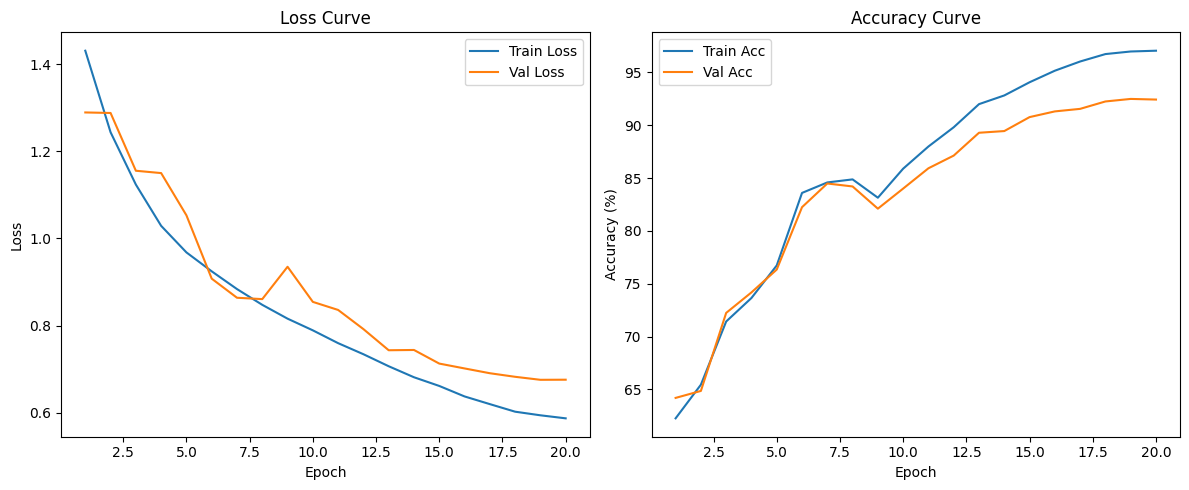

In [13]:
import torch.optim as optim
import importlib
import model_train
importlib.reload(model_train)  # 确保当前 Jupyter 内核使用刚更新的 Trainer
from model_train import Trainer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

# CIFAR-10 常用配置：SGD + Nesterov + L2 正则 + 余弦退火。
epochs = 20
optimizer = optim.SGD(
    model.parameters(), lr=0.05, momentum=0.9, weight_decay=5e-4, nesterov=True
)
criterion = torch.nn.CrossEntropyLoss(label_smoothing=0.1)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)
trainer = Trainer(
    model=model,
    trainloader=trainloader,
    valloader=valloader,
    optimizer=optimizer,
    lr=0.05,
    momentum=0.9,
    device=device,
    early_stop=True,
    early_stop_mode='val_acc',
    patience=10,
    save_path='cifar10_best_resnet18_model.pth',
    criterion=criterion,
    scheduler=scheduler,
)

trainer.train(epochs=epochs)

# evaluating 的返回顺序是 (accuracy, average_loss)。
val_acc, val_loss = trainer.evaluating(valloader)
print(f"验证集损失: {val_loss:.4f}, 验证集准确率: {val_acc:.2f}%")
trainer.plot_metrics(acc=True)

# 测试集预测与提交

In [ ]:
# # 测试集预测并将结果写入 sampleSubmission.csv
# import os
# import pandas as pd
# import torch
# from PIL import Image
# from torch.utils.data import Dataset, DataLoader

# test_dir = r"E:/王道python项目班/Data/cifar-10/test/test"
# submission_path = r"E:/王道python项目班/Data/cifar-10/sampleSubmission.csv"
# checkpoint_path = "cifar10_best_model.pth"

# class Cifar10TestDataset(Dataset):
#     def __init__(self, folder, transform=None):
#         self.folder = folder
#         self.transform = transform
#         self.img_files = [
#             os.path.join(folder, name)
#             for name in os.listdir(folder)
#             if name.lower().endswith((".jpg", ".jpeg", ".png"))
#         ]
#         # 必须按数字 ID 排序，不能按字符串排序。
#         self.img_files.sort(
#             key=lambda path: int(os.path.splitext(os.path.basename(path))[0])
#         )

#     def __len__(self):
#         return len(self.img_files)

#     def __getitem__(self, index):
#         img_path = self.img_files[index]
#         image = Image.open(img_path).convert("RGB")
#         image_id = int(os.path.splitext(os.path.basename(img_path))[0])
#         if self.transform is not None:
#             image = self.transform(image)
#         return image, image_id

# test_dataset = Cifar10TestDataset(test_dir, transform=transform)
# test_loader = DataLoader(
#     test_dataset,
#     batch_size=512,
#     shuffle=False,
#     num_workers=0,  # Windows/Jupyter 下使用 0 最稳妥
#     pin_memory=torch.cuda.is_available(),
# )
# print(f"测试集大小: {len(test_dataset)}")

# # 加载训练阶段保存的最佳权重。
# if not os.path.exists(checkpoint_path):
#     raise FileNotFoundError(
#         f"未找到 {checkpoint_path}，请先运行上面的训练单元生成最佳模型权重。"
#     )
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))
# model = model.to(device)
# model.eval()

# predicted_ids = []
# predicted_labels = []
# with torch.inference_mode():
#     for images, image_ids in test_loader:
#         images = images.to(device, non_blocking=True)
#         class_indices = model(images).argmax(dim=1).cpu().tolist()
#         predicted_ids.extend(image_ids.tolist())
#         predicted_labels.extend(classes[index] for index in class_indices)

# prediction_df = pd.DataFrame({"id": predicted_ids, "label": predicted_labels})
# if prediction_df["id"].duplicated().any():
#     raise ValueError("测试图片 ID 存在重复，无法生成可靠提交文件。")

# # 以附件二的 ID 顺序为准写回，避免图片遍历顺序造成错位。
# submission_df = pd.read_csv(submission_path)
# if len(submission_df) != len(prediction_df):
#     raise ValueError(
#         f"提交模板有 {len(submission_df)} 行，但预测得到 {len(prediction_df)} 行。"
#     )
# submission_df = submission_df[["id"]].merge(
#     prediction_df, on="id", how="left", validate="one_to_one"
# )
# if submission_df["label"].isna().any():
#     missing_ids = submission_df.loc[submission_df["label"].isna(), "id"].head().tolist()
#     raise ValueError(f"以下测试 ID 没有预测结果（仅显示前几个）: {missing_ids}")

# submission_df.to_csv(submission_path, index=False)
# print(f"预测完成，已写入: {submission_path}")
# print(submission_df.head())
# print(submission_df["label"].value_counts().sort_index())